# Train model

In [1]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [2]:
filename = os.path.join(context['portfolio_dir'], "features.parquet")
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(378115, 42)

## EDA

In [3]:
df.describe()

,AUDUSD,BZ,EURUSD,GBPUSD,GC,NZDUSD,USDCAD,USDCHF,USDJPY,^DJI,...,target,time_since_high,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume_shock,volume_zscore,zscore_20
count,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,...,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000,378115.000000
mean,0.656438,75.650401,1.106191,1.292307,2843.412298,0.596627,1.374805,0.857660,149.426762,40995.827468,...,0.049906,437.444518,0.018077,0.042764,0.050107,0.871980,0.937824,1.025242,0.029950,0.115806
std,0.018834,8.551772,0.043360,0.041691,890.960384,0.018146,0.028978,0.043688,5.714572,4717.306165,...,1.261941,354.657921,0.132526,0.036251,0.037706,0.276480,0.372480,0.633444,1.046235,1.309730
min,0.595529,58.919998,1.024443,1.207846,1816.599976,0.551849,1.311250,0.763200,133.464996,32417.589844,...,-3.000000,0.000000,-0.677732,0.000489,0.001239,0.003949,0.005714,0.000049,-2.978150,-4.194141
25%,0.644950,68.519997,1.076658,1.262053,2033.000000,0.584300,1.356400,0.808670,145.608002,37735.109375,...,-0.653682,75.000000,-0.046064,0.020854,0.026544,0.670259,0.672181,0.693273,-0.643553,-0.943603
50%,0.655471,75.300003,1.092538,1.280651,2620.300049,0.597100,1.370210,0.872700,149.259003,41249.378906,...,0.059726,429.000000,0.010650,0.032942,0.040149,0.889927,0.880115,0.891922,-0.241210,0.180286
75%,0.667080,82.339996,1.152326,1.332679,3336.899902,0.610400,1.388650,0.895230,154.255005,44546.078125,...,0.770453,722.000000,0.070062,0.052905,0.062111,1.089580,1.137582,1.170767,0.423095,1.170205
max,0.712921,103.139999,1.201764,1.382533,5318.399902,0.639190,1.471700,0.920970,161.606995,50188.140625,...,3.000000,1249.000000,4.246774,0.991639,0.843848,1.448208,2.480680,19.275672,4.248432,4.238351


In [4]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 378115 entries, 475 to 618351
Data columns (total 40 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AUDUSD                 378115 non-null  float64
 1   BZ                     378115 non-null  float64
 2   EURUSD                 378115 non-null  float64
 3   GBPUSD                 378115 non-null  float64
 4   GC                     378115 non-null  float64
 5   NZDUSD                 378115 non-null  float64
 6   USDCAD                 378115 non-null  float64
 7   USDCHF                 378115 non-null  float64
 8   USDJPY                 378115 non-null  float64
 9   ^DJI                   378115 non-null  float64
 10  ^GSPC                  378115 non-null  float64
 11  ^IXIC                  378115 non-null  float64
 12  ^RUT                   378115 non-null  float64
 13  ^VIX1D                 378115 non-null  float64
 14  close_range            378115 non-null  float64
 1

In [5]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

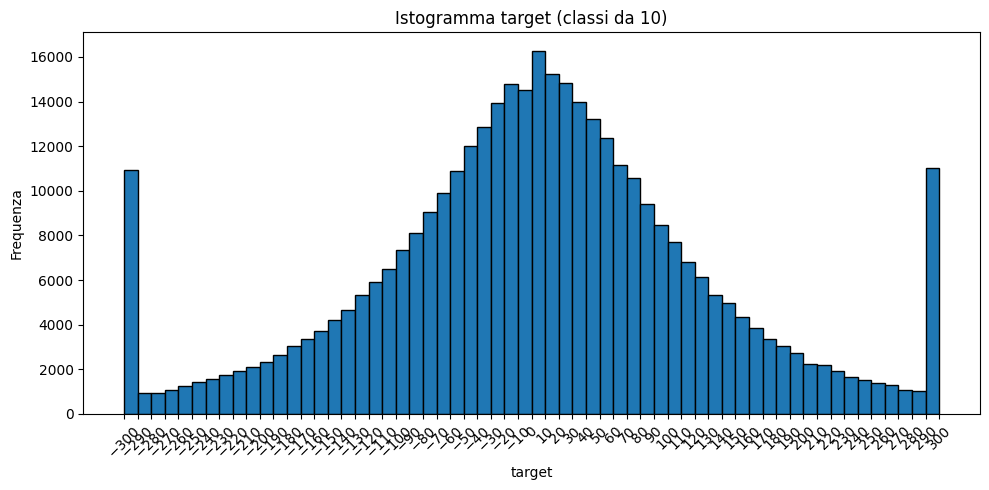

In [6]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

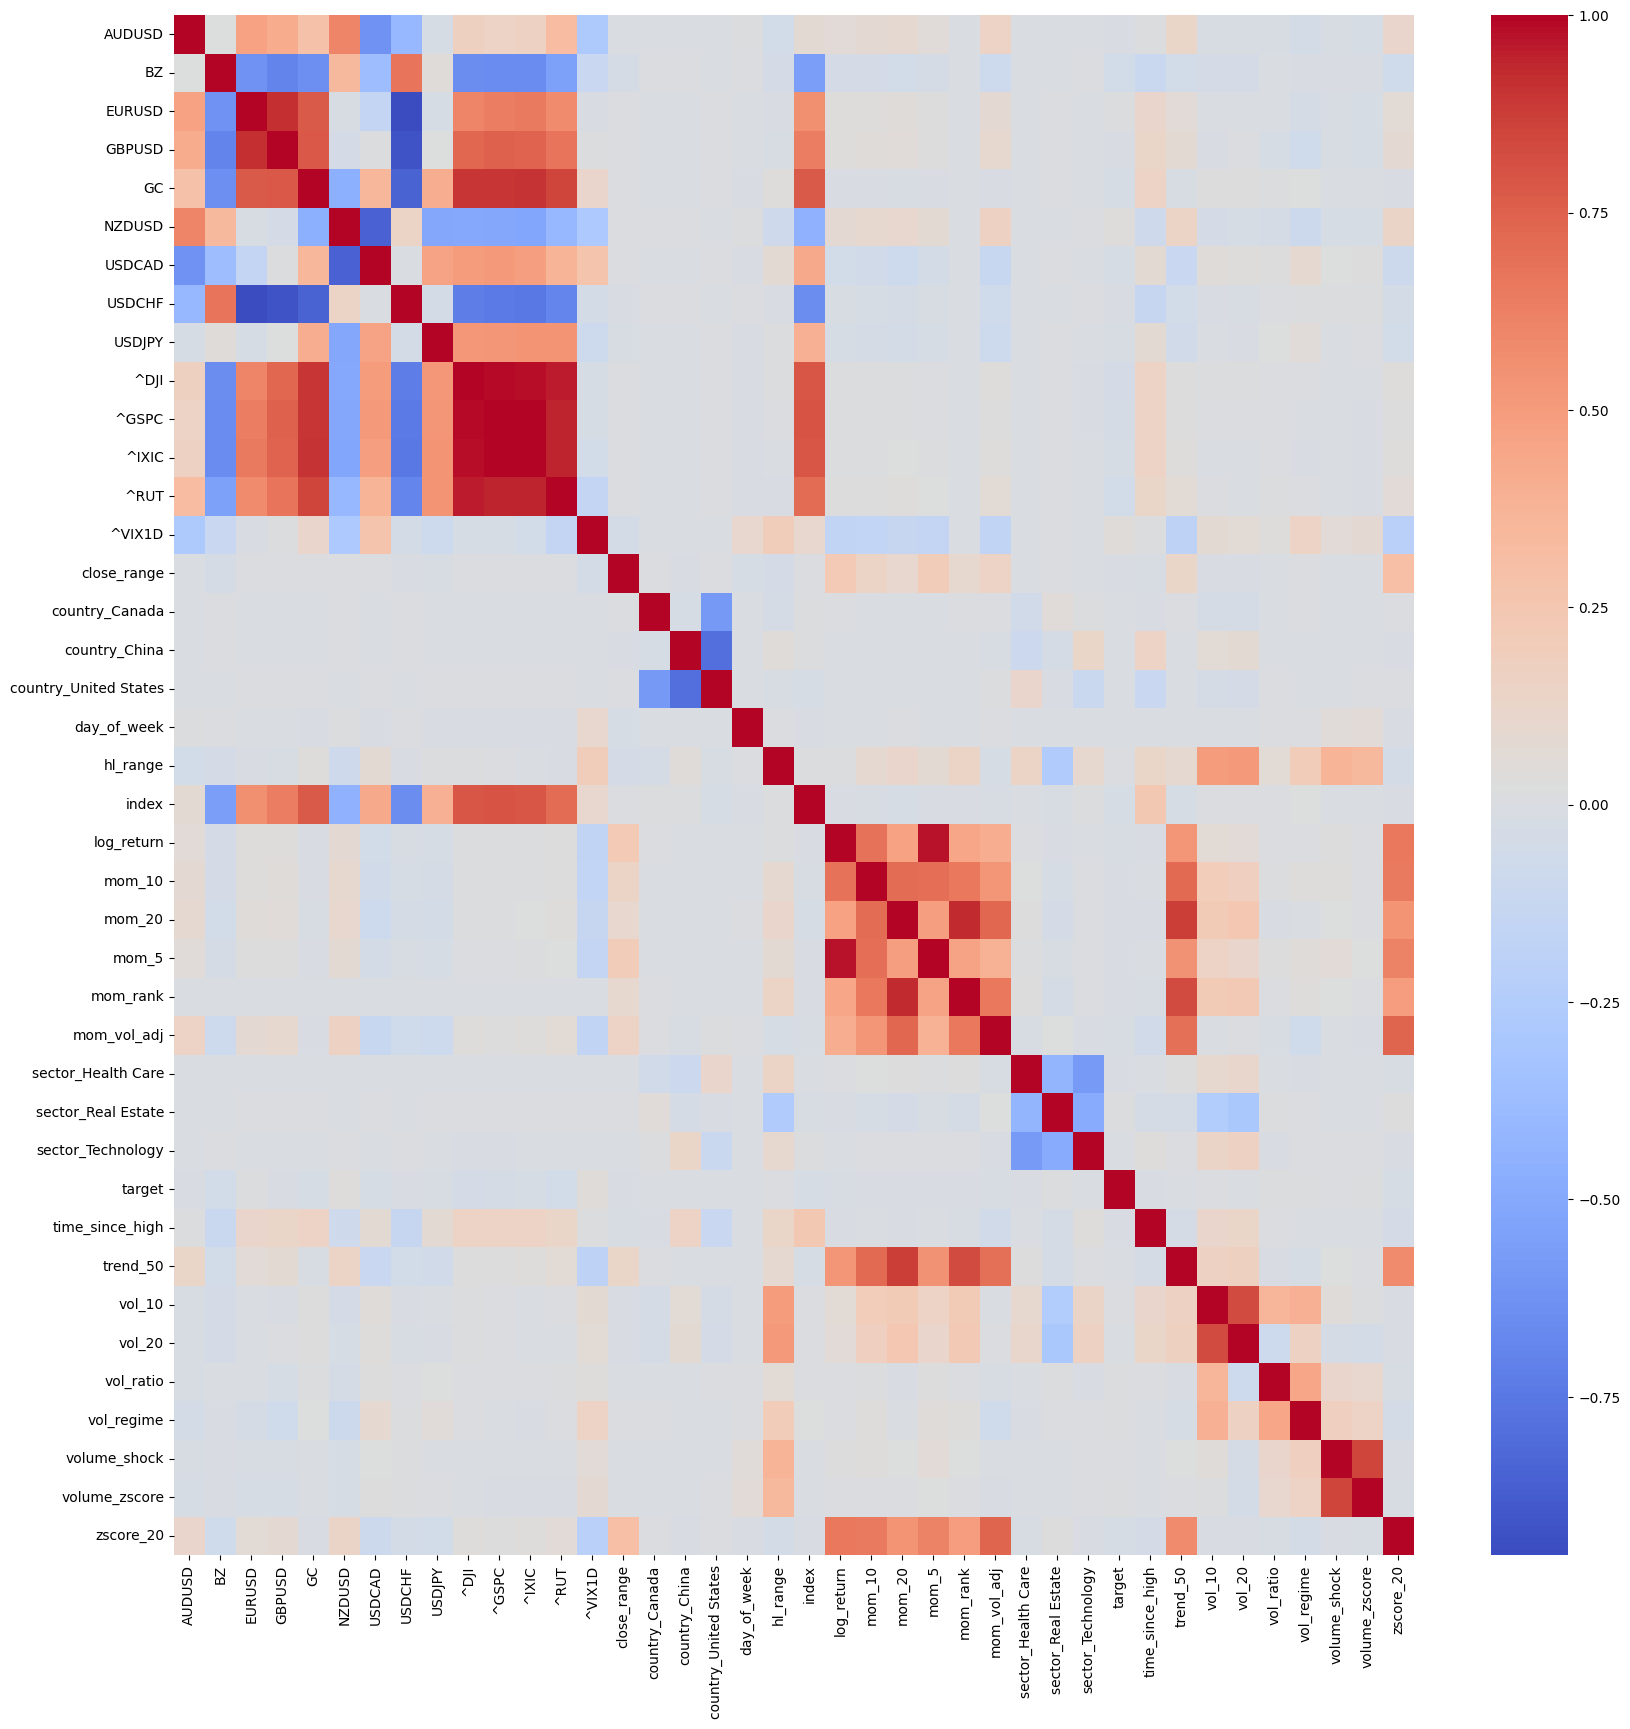

In [7]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [8]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

## Model building

In [9]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [10]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (378115,)
Data Shape: (378115, 39)
Train Data Shape: (302492, 39)
Train Labels Shape: (302492,)
Test Data Shape: (75623, 39)
Test Labels Shape: (75623,)


In [11]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(100, activation='relu',name='layerDense1'))
model.add(Dense(80, activation='relu',name='layerDense2'))
model.add(Dense(20, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 100)            │         4,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 20)             │         1,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,721 (53.60 KB)

 Trainable params: 13,721 (53.60 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/30
1891/1891 - 3s - 2ms/step - loss: 0.0423 - val_loss: 0.0418
Epoch 2/30
1891/1891 - 3s - 1ms/step - loss: 0.0408 - val_loss: 0.0404
Epoch 3/30
1891/1891 - 3s - 2ms/step - loss: 0.0399 - val_loss: 0.0394
Epoch 4/30
1891/1891 - 2s - 1ms/step - loss: 0.0391 - val_loss: 0.0395
Epoch 5/30
1891/1891 - 2s - 1ms/step - loss: 0.0385 - val_loss: 0.0390
Epoch 6/30
1891/1891 - 2s - 1ms/step - loss: 0.0380 - val_loss: 0.0377
Epoch 7/30
1891/1891 - 2s - 1ms/step - loss: 0.0376 - val_loss: 0.0379
Epoch 8/30
1891/1891 - 2s - 1ms/step - loss: 0.0371 - val_loss: 0.0373
Epoch 9/30
1891/1891 - 3s - 1ms/step - loss: 0.0369 - val_loss: 0.0370
Epoch 10/30
1891/1891 - 2s - 1ms/step - loss: 0.0366 - val_loss: 0.0366
Epoch 11/30
1891/1891 - 2s - 1ms/step - loss: 0.0362 - val_loss: 0.0367
Epoch 12/30
1891/1891 - 2s - 1ms/step - loss: 0.0361 - val_loss: 0.0365
Epoch 13/30
1891/1891 - 2s - 1ms/step - loss: 0.0358 - val_loss: 0.0359
Epoch 14/30
1891/1891 - 2s - 1ms/step - loss: 0.0357 - val_loss: 0.0362
E

Model saved to: data\model\model.keras


In [13]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.04491801 0.89225316
Label: 0.8097, Prediction: -0.0327
Label: -1.2314, Prediction: -0.1962
Label: -0.2090, Prediction: 0.4307
Label: 1.8341, Prediction: -0.1374
Label: 1.9638, Prediction: 1.4695
Label: -3.0000, Prediction: -0.6278
Label: 2.6213, Prediction: 0.1084
Label: 2.7577, Prediction: -0.3270
Label: -0.9707, Prediction: -0.2365
Label: 0.5925, Prediction: 0.1083
Label: -0.3034, Prediction: 0.6494
Label: 0.8968, Prediction: 0.2883
Label: -0.0508, Prediction: 0.4981
Label: -1.1602, Prediction: -0.1066
Label: 0.9626, Prediction: 0.2775
Label: 0.4039, Prediction: 0.0136
Label: 0.6667, Prediction: -0.1900
Label: -0.0931, Prediction: -1.4827
Label: 1.7671, Prediction: 0.5306
Label: 0.5373, Prediction: 0.3691
Label: 0.2309, Prediction: -0.3137
Label: -0.7308, Prediction: 0.1391
Label: -1.9886, Prediction: -0.7440
Label: -0.7036, Prediction: 0.2116
Label: 1.2125, Prediction: 0.4078
Label: 0.2089, Prediction: 0.6525
Label: -0.6458, Prediction: 0.3395
Label: -1